In [4]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [9]:
n_qubits = 8
n_layers = 3

dev = qml.device("lightning.gpu",wires=n_qubits)

In [10]:
@qml.qnode(dev)
def circuit(weights):

    for layer in range(n_layers):
    
        for q in range(n_qubits):
            qml.RY(weights[layer, q],wires=q)

        for q in range(n_qubits-1):
            qml.CNOT(wires=[q,q + 1])

    return qml.expval(qml.PauliZ(0))

[[ 1.56828392 -2.63459565 -0.99027772 -0.45731564 -0.20418606 -1.04743495
   0.09208679 -2.34819481]
 [-0.20558766 -0.89167972 -2.65809996 -2.66716586  3.06607395  1.16846917
  -2.69928777  1.79719915]
 [-2.31326538  1.40303847 -2.186329    3.12819104 -2.32666736  2.82987278
   0.44733257 -1.12228383]]


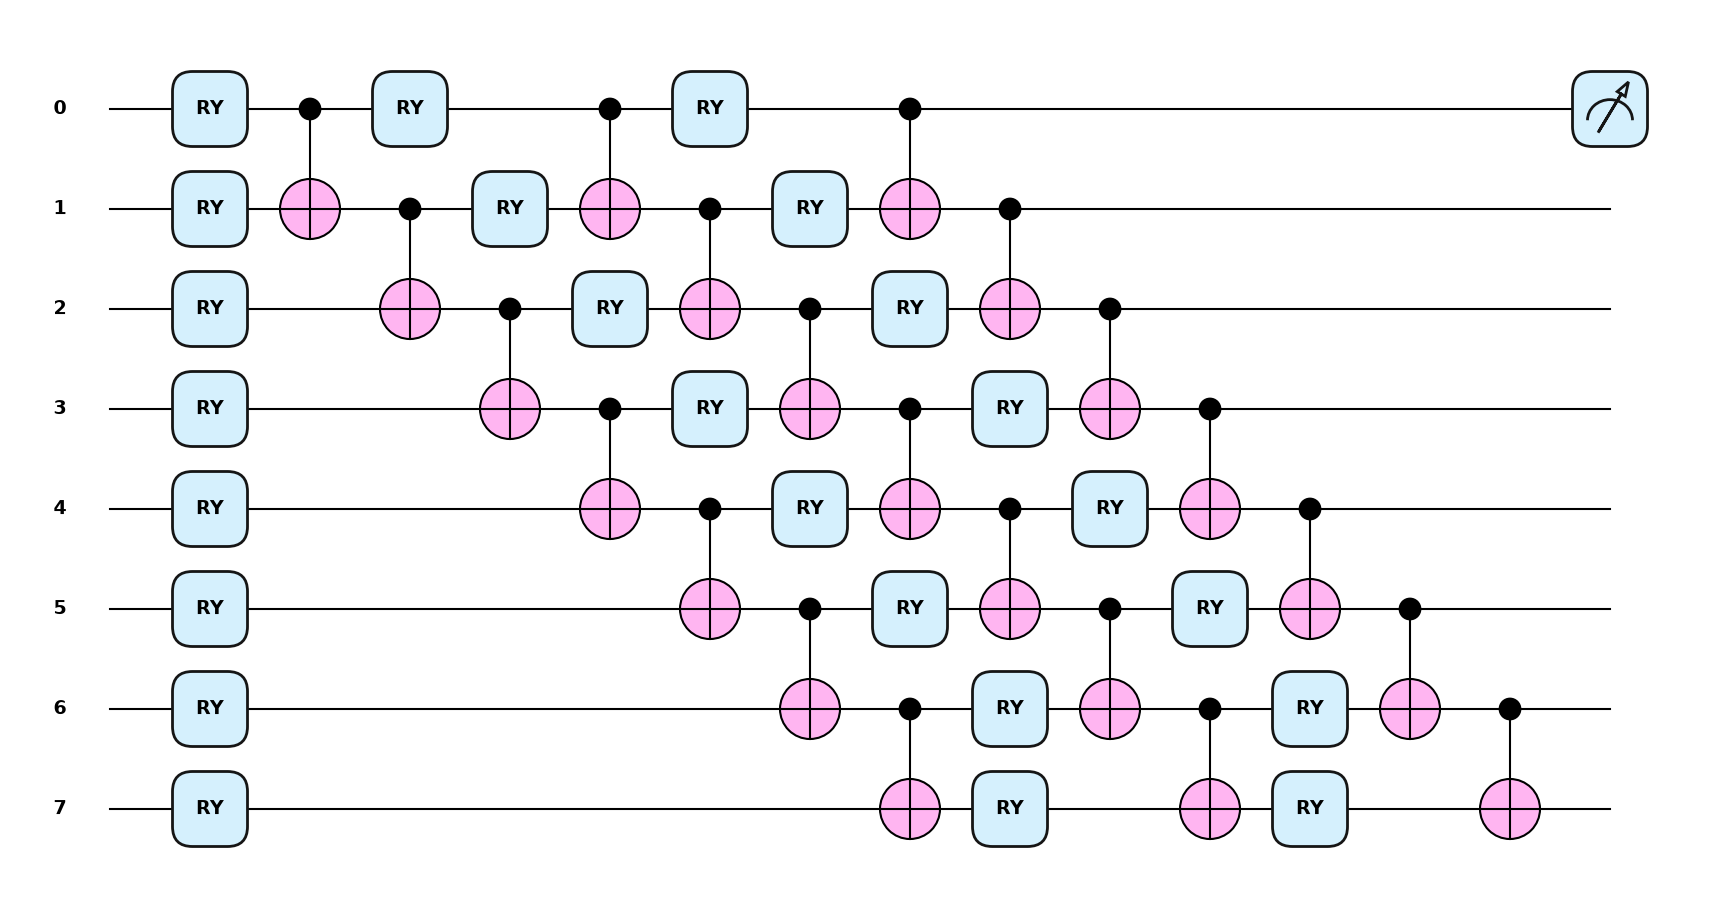

In [11]:
weights = np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits),requires_grad=True)
print(weights)
qml.draw_mpl(circuit,style='pennylane')(weights);

In [179]:
result = circuit(weights)

print(result)

-0.05073142116224022


In [180]:
gradient = qml.grad(circuit)(weights)
print(gradient)

[[ 5.33054644e-01  3.01335710e-01  3.85454127e-01 -5.55111512e-17
   3.81639165e-17  2.77555756e-17  8.32667268e-17 -3.81639165e-17]
 [ 7.25379323e-01 -4.50422644e-01 -4.77048956e-17  6.93889390e-18
  -3.12250226e-17  1.90819582e-17 -2.77555756e-17  6.07153217e-17]
 [-1.71228409e-01 -5.37764278e-17 -3.12250226e-17  5.20417043e-18
  -1.04083409e-17  2.81892565e-17  1.38777878e-17  1.38777878e-17]]


In [184]:
#1st test

n_trials = 1000
gradients = []

for trials in range(n_trials):

    weights = np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits),requires_grad=True)

    gradient = qml.grad(circuit)(weights)

    gradients.append(gradient)

In [185]:
gradients = np.array(gradients)
parameter_gradients = gradients[:,0,0]

mean = np.mean(parameter_gradients)
variance = np.var(parameter_gradients)
deviation = np.std(parameter_gradients)

print(parameter_gradients[:10])
print(mean)
print(variance)
print(deviation)

#for n = 4 var = 0.224397860761738, 0.23796733674128637
#n = 6 0.24755993637102627, 0.23575859786200715
#n = 8 0.2441412835444209, 0.23149393417119404

[-0.31358427  0.07622144 -0.11407146  0.39572645  0.31355547  0.51160255
 -0.37445546  0.06780687 -0.48129146  0.50599348]
-0.0017725240978802147
0.23149393417119404
0.4811381653654115


<function matplotlib.pyplot.show(close=None, block=None)>

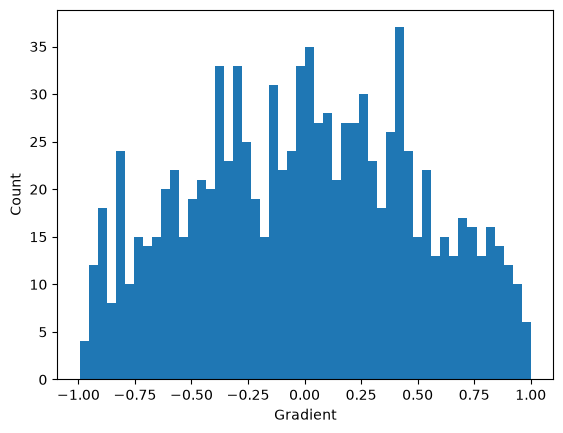

In [183]:
plt.hist(parameter_gradients, bins=50)
plt.xlabel("Gradient")
plt.ylabel("Count")
plt.show

In [12]:
#speed testing CPU vs GPU

import time

start = time.perf_counter()

n_trials = 100

for trials in range(n_trials):

    weights = np.random.uniform(-np.pi,np.pi,size=(n_layers,n_qubits),requires_grad=True)

    gradient = qml.grad(circuit)(weights)

elapsed = time.perf_counter() - start

print(f"{n_trials} trials: {elapsed:.2f} seconds")

# CPU 100 Trials @ 1.23s
# GPU 100 Trials @ 0.64


100 trials: 0.64 seconds
